# splicescope — a guided tour

This notebook walks through the whole splicescope pipeline end to end, on a small
**synthetic** dataset so it runs anywhere with no downloads. We'll go from raw splice
junctions to:

1. a **junction taxonomy** (annotated / novel / cryptic),
2. **splice-site usage** (Ψ),
3. **event-level PSI** for the four rMATS-style event classes (SE / MXE / A5SS / A3SS),
4. **differential splicing** between two conditions, and
5. a cross-validated **classifier** that prioritises genuine cryptic events over noise.

The last section shows how to point the exact same code at your own STAR `SJ.out.tab`
files instead of the simulator.

> **Running on Google Colab?** Run this first, then restart the runtime:
> `!pip install git+https://github.com/elmasnuryilmaz/splicescope`


In [1]:
import pandas as pd

from splicescope import annotate, cryptic, diff, events, plotting, quantify
from splicescope.ml import CrypticClassifier
from splicescope.simulate import simulate_dataset

# activate the inline backend *after* importing plotting (which sets Agg), so
# figures are captured in the notebook
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 12)


## 1. A dataset with known ground truth

`simulate_dataset` builds a tiny annotated genome and emits per-sample junctions that
mimic STAR: canonical introns, true cryptic-exon events (up-regulated in condition **B**),
alternative 5′/3′ splice sites, mutually exclusive exons, and noise. `label_noise` flips a
few ground-truth labels to make the ML task realistically hard.


In [2]:
ds = simulate_dataset(
    n_genes=20, n_per_group=6,
    cryptic_fraction=0.6, alt_ss_fraction=0.4, mxe_fraction=0.3,
    label_noise=0.08, seed=1,
)
n_junc = ds.observed[["chrom", "start", "end", "strand"]].drop_duplicates().shape[0]
print(f"{ds.observed['sample'].nunique()} samples, {n_junc} unique junctions")
ds.observed.head()


12 samples, 198 unique junctions


,chrom,start,end,strand,motif,annotated_star,count,sample,is_cryptic_truth
0,chr1,1120,1619,+,GT/AG,0,210,A0,0
1,chr1,1120,1619,+,GT/AG,0,190,A1,0
2,chr1,1120,1619,+,GT/AG,0,180,A2,0
3,chr1,1120,1619,+,GT/AG,0,212,A3,0
4,chr1,1120,1619,+,GT/AG,0,224,A4,0


## 2. Classify every junction

Each observed junction is labelled by how it relates to the reference: `annotated`,
`novel_donor`, `novel_acceptor`, `novel_combination`, or `cryptic` (both splice sites
unannotated — the strongest cryptic prior).


In [3]:
annotated = annotate.annotate_junctions(ds.observed, ds.known)
summary = annotate.annotation_summary(annotated)
summary


,sclass,n_junctions
0,annotated,74
1,novel_combination,0
2,novel_donor,36
3,novel_acceptor,48
4,cryptic,40


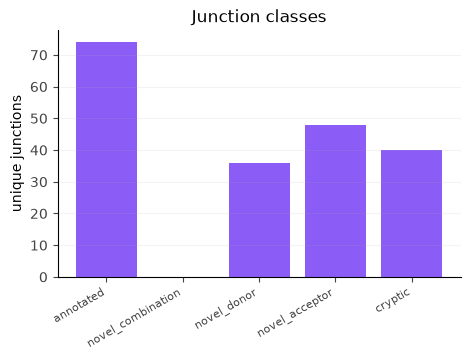

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
plotting.plot_annotation_summary(summary, ax=ax)
plt.show()


## 3. Splice-site usage (Ψ)

Ψ is model-free: for a junction it is the fraction of its splice site's reads that flow
through it. Thinly covered sites become `NaN` rather than a noisy ratio.


In [5]:
psi = quantify.compute_psi(annotated, min_reads=5)
psi.loc[psi["sclass"] != "annotated",
        ["chrom", "start", "end", "sclass", "sample", "count", "psi_donor"]].head()


,chrom,start,end,sclass,sample,count,psi_donor
888,chr1,1120,1219,novel_acceptor,A0,12,0.054054
889,chr1,1120,1219,novel_acceptor,A1,5,0.024272
890,chr1,1120,1219,novel_acceptor,A2,3,0.016393
891,chr1,1120,1219,novel_acceptor,A3,3,0.013953
892,chr1,1120,1219,novel_acceptor,A4,3,0.013216


## 4. Event-level PSI — SE / MXE / A5SS / A3SS

Beyond usage, splicescope reconstructs canonical splicing *events* from junctions and
computes rMATS-style percent-spliced-in for each. It covers four of the five rMATS event
classes (intron retention needs read coverage and is out of scope).


In [6]:
evs = events.detect_events(annotated)
evs["event_type"].value_counts()


event_type
A3SS    19
SE      16
A5SS     9
MXE      6
Name: count, dtype: int64

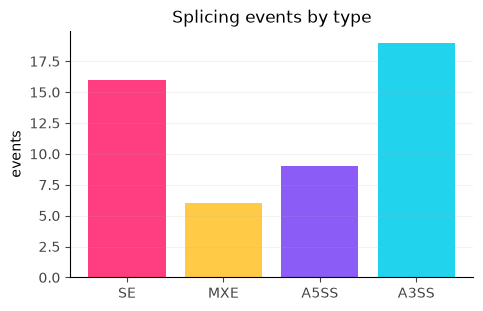

In [7]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
plotting.plot_event_summary(evs, ax=ax)
plt.show()


## 5. Differential splicing between conditions

For each junction (and each event) we compare per-sample Ψ between conditions with a
Mann–Whitney U test and Benjamini–Hochberg FDR. Positive ΔΨ means more inclusion in B.


46 significant junctions (q<=0.05, |ΔΨ|>=0.1)


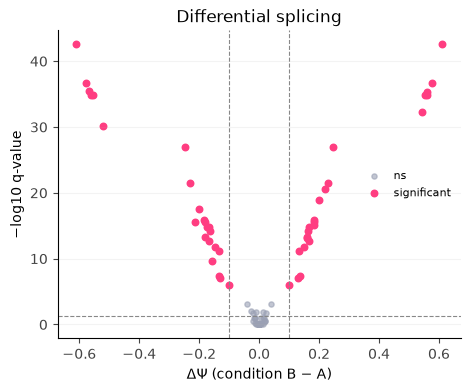

In [8]:
dsplice = diff.differential_splicing(psi, ds.groups)
print(len(diff.significant(dsplice)), "significant junctions (q<=0.05, |ΔΨ|>=0.1)")

fig, ax = plt.subplots(figsize=(5.2, 4))
plotting.plot_volcano(dsplice, ax=ax)
plt.show()


In [9]:
# the same differential test, at the event level
epsi = events.event_psi(annotated, evs, min_reads=5)
ediff = diff.differential_splicing(epsi, ds.groups, value="psi", key=["event_id"])
ediff.head(6)[["event_id", "event_type", "delta_psi", "qvalue"]]


,event_id,event_type,delta_psi,qvalue
0,MXE:chr1:99340-99839:+@99390-99430|99490-99530,MXE,-0.612963,2.437268e-53
1,MXE:chr1:112780-113279:+@112830-112870|112930-...,MXE,-0.580069,6.294629e-46
2,A3SS:chr1:15180:+,A3SS,-0.568400,2.064945e-44
3,MXE:chr1:15180-15679:+@15230-15270|15330-15370,MXE,-0.572478,3.237986e-44
4,MXE:chr1:93240-93739:+@93290-93330|93390-93430,MXE,-0.556013,3.533319e-44
5,MXE:chr1:51780-52279:+@51830-51870|51930-51970,MXE,-0.561359,5.818598e-44


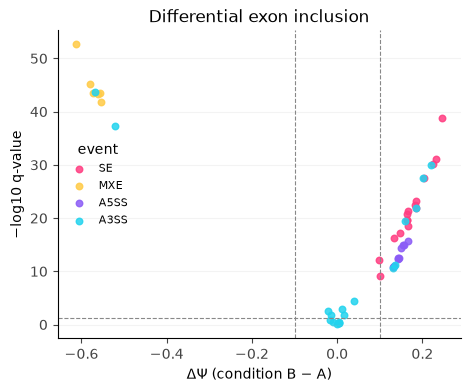

In [10]:
fig, ax = plt.subplots(figsize=(5.2, 4))
plotting.plot_event_volcano(ediff, ax=ax)
plt.show()


## 6. Prioritising cryptic events with a classifier

Novel junctions are dominated by noise. Rather than hand-tuning thresholds, we train a
RandomForest on engineered features and evaluate it with **stratified cross-validation**
(no leakage). Every model ships with a model card.


In [11]:
feats = cryptic.extract_features(psi, ds.known)
clf = CrypticClassifier(random_state=0)
metrics = clf.evaluate(feats)
clf.fit(feats)
metrics


{'n_junctions': 124,
 'n_positive': 36,
 'n_splits': 5,
 'roc_auc': 0.8390151515151514,
 'average_precision': 0.7084737497359195}

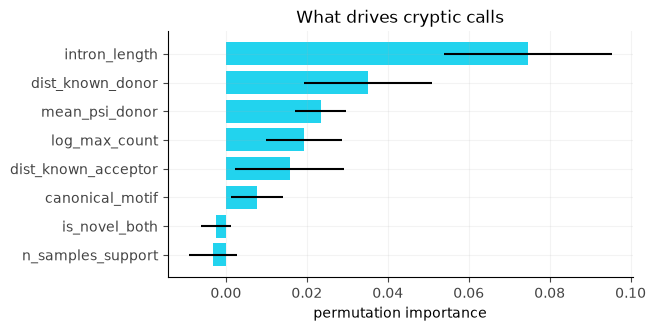

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.2))
plotting.plot_importance(clf.importances, ax=ax)
plt.show()


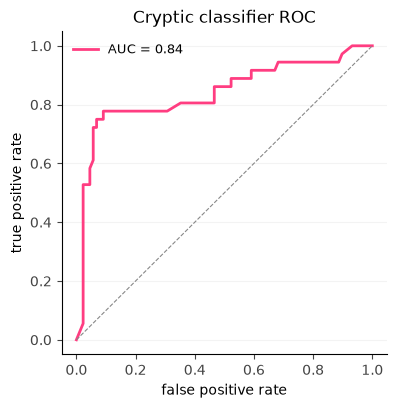

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

x, y = clf._xy(feats)
oof = cross_val_predict(
    clf._make_pipeline(), x, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba",
)[:, 1]

fig, ax = plt.subplots(figsize=(4.2, 4.2))
plotting.plot_roc(y, oof, ax=ax)
plt.show()


In [14]:
# highest-scoring candidate cryptic junctions
clf.score_table(feats).head(8)[
    ["chrom", "start", "end", "sclass", "cryptic_score"]
]


,chrom,start,end,sclass,cryptic_score
0,chr1,118421,118759,novel_donor,1.0
1,chr1,98720,98819,novel_acceptor,1.0
2,chr1,57880,57979,novel_acceptor,1.0
3,chr1,74320,74419,novel_acceptor,1.0
4,chr1,21441,21779,novel_donor,1.0
5,chr1,21280,21379,novel_acceptor,1.0
6,chr1,98881,99219,novel_donor,1.0
7,chr1,106841,107179,novel_donor,1.0


## 7. Which pathways are affected? (ORA)

Given the differentially spliced genes, `enrich` runs a hypergeometric
over-representation test (the same statistic as clusterProfiler) against any gene sets.
Here we use a couple of **illustrative** sets; in practice you load real GO / KEGG /
MSigDB sets with `io.read_gmt("sets.gmt")`.


In [15]:
from splicescope import enrich

sig_genes = diff.significant(ediff, q=0.1, min_delta=0.1)["gene_id"].dropna().unique().tolist()
gene_sets = {
    "calcium_signaling (demo)": sig_genes[:4] + ["g19"],
    "unrelated_pathway (demo)": ["g15", "g16", "g17", "g18"],
}
enrich.enrich_differential(ediff, gene_sets, q=0.1, min_delta=0.1)


,term,set_size,overlap,n_hits,n_background,fold_enrichment,bias_odds,pvalue,qvalue,genes
0,calcium_signaling (demo),5,5,20,20,1.0,0.854545,1.0,1.0,"g02,g15,g16,g18,g19"
1,unrelated_pathway (demo),4,4,20,20,1.0,0.988235,1.0,1.0,"g15,g16,g17,g18"


## 8. Using your own data

Everything above works on real STAR output — just replace the simulator with the readers.
Given a folder of `*.SJ.out.tab` files, a reference GTF, and a `sample,condition` table:

```python
from splicescope import io

observed = io.read_many_star_sj({
    "ctrl1": "sj/ctrl1.SJ.out.tab",
    "ctrl2": "sj/ctrl2.SJ.out.tab",
    "kd1":   "sj/kd1.SJ.out.tab",
    "kd2":   "sj/kd2.SJ.out.tab",
})
known  = io.read_gtf_junctions("annotation.gtf")
groups = {"ctrl1": "ctrl", "ctrl2": "ctrl", "kd1": "kd", "kd2": "kd"}

annotated = annotate.annotate_junctions(observed, known)
psi       = quantify.compute_psi(annotated)
result    = diff.differential_splicing(psi, groups)
```

Or from the command line:

```bash
splicescope run --sj-dir sj/ --gtf annotation.gtf --groups groups.tsv --outdir results
```

That's the whole tour — from junctions to events to cryptic calls, reproducibly.
